In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
import json
import joblib


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df.head()


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
3,2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
4,2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [4]:
target = "load_actual"

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]


In [5]:
X_train = train[feature_names]
X_test = test[feature_names]

y_train = train[target]
y_test = test[target]


In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [8]:
svm = SVR(kernel='rbf', C=180, gamma='scale')
svm.fit(X_train_scaled, y_train)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,180
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [9]:
y_pred_svm = svm.predict(X_test_scaled)

mae_svm = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100

print("SVM MAE :", mae_svm)
print("SVM RMSE:", rmse_svm)
print("SVM MAPE:", mape_svm)


SVM MAE : 900.1138323358534
SVM RMSE: 1121.5993390410376
SVM MAPE: 9.468651368877069


In [10]:
joblib.dump(svm, "../saved_models/svm_model.pkl")


['../saved_models/svm_model.pkl']

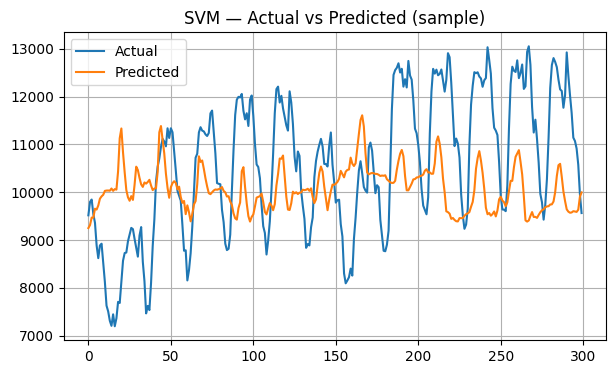

In [11]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_svm[:300], label="Predicted")
plt.title("SVM — Actual vs Predicted (sample)")
plt.legend()
plt.grid(True)
plt.show()